# Project 2
ECE 232E Summer 2026 - Project 2: Social Network Mining 
Posted: Sunday, June 12, 2026  
Due: Sunday, July 26, 2026 at 11:59 PM PST

By Enoch Yeo 906630606 / Nicolas Jeong Lee 605309755 / James Chen 005399315

## 1. Facebook Network

### 1. Structural Properties of the Facebook Network

#### 1.

In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random
import matplotlib.cm as cm
from matplotlib.collections import LineCollection

g = ig.Graph.Read_Edgelist("facebook_combined.txt", directed=False)

##### 1.1

In [2]:
print("Number of Nodes = ", g.vcount())
print("Number of Edges = ", g.ecount())

Number of Nodes =  4039
Number of Edges =  88234


##### 1.2

In [3]:
print("Connected = ", g.is_connected())

Connected =  True


#### 2

In [4]:
print("Diameter = ", g.diameter())

Diameter =  8


#### 3

Average Degree =  43.69101262688784
rough log-log slope: -1.1801644192508813


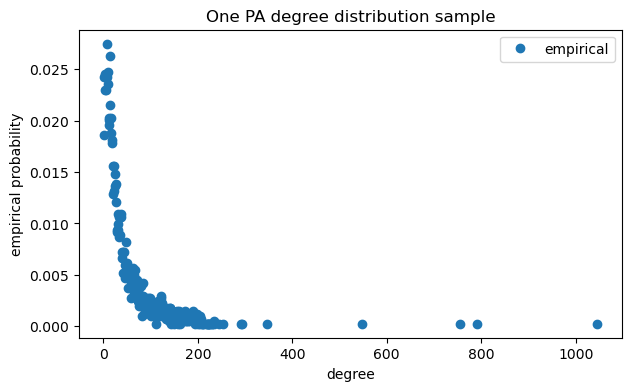

In [5]:
deg = np.asarray(g.degree())
print("Average Degree = ", sum(deg)/g.vcount())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.plot(k, prob, "o", label="empirical")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

#### 4

rough log-log slope: -1.1801644192508813


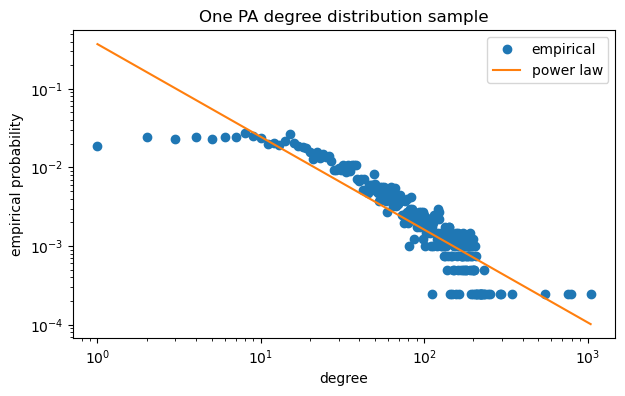

In [6]:
deg = np.asarray(g.degree())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.loglog(k, prob, "o", label="empirical")
plt.loglog(k, np.exp(intercept) * k**slope, label="power law")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

### 2. Personalized Network

#### 5

In [7]:
nodes = [0] + g.neighbors(0)
pn = g.induced_subgraph(nodes)
print("Number of Nodes = ", pn.vcount())
print("Number of Edges = ", pn.ecount())

Number of Nodes =  348
Number of Edges =  2866


#### 6

In [8]:
print("Diameter = ", pn.diameter())

Diameter =  2


Provide upper and lower bound of the diameter

#### 7

Write the answer

### 3. Core node's personalized network

#### 8

In [9]:
count = 0
core_node = []
for node in range(0, g.vcount()):
    if len(g.neighbors(node)) > 200:  
        core_node.append(node)
        count += 1
print("Core Nodes = ", core_node)
print("Num of Core Nodes = ", count)

total_degree = 0
for node in core_node:
    total_degree += g.degree(node)
print("Average Degree of Core Nodes = ", total_degree / len(core_node))

Core Nodes =  [0, 107, 348, 483, 1086, 1199, 1352, 1431, 1584, 1589, 1663, 1684, 1730, 1746, 1768, 1800, 1827, 1888, 1912, 1941, 1985, 1993, 2047, 2078, 2123, 2142, 2206, 2218, 2229, 2233, 2240, 2266, 2347, 2410, 2464, 2507, 2543, 2560, 2611, 3437]
Num of Core Nodes =  40
Average Degree of Core Nodes =  279.375


### 3.1 Core node's personalized network

#### 9

In [10]:
def get_communities(g):
    results = {}

    # Fast-Greedy
    fg = g.community_fastgreedy()
    results["Fast-Greedy"] = fg.as_clustering()

    # Edge-Betweenness
    eb = g.community_edge_betweenness()
    results["Edge-Betweenness"] = eb.as_clustering()

    # Infomap
    results["Infomap"] = g.community_infomap()

    return results

def draw(pn, clustering, coords, ax, title):
    segs = [(coords[e.source], coords[e.target]) for e in pn.es]
    ax.add_collection(LineCollection(segs, colors="lightgray",
                                     linewidths=0.4, zorder=1))
    k = max(len(clustering), 1)
    cmap = cm.get_cmap("tab20", k)
    colors = [cmap(m) for m in clustering.membership]
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
    ax.scatter(xs, ys, c=colors, s=40, zorder=2,
               edgecolors="black", linewidths=0.3)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")

def plot_node(node_id):
    """node_id = edgelist index (graph ID - 1)."""
    pn = g.induced_subgraph([node_id] + g.neighbors(node_id))
    coords = pn.layout("fr").coords
    results = get_communities(pn)

    print(f"Core Node ID {node_id + 1}  (|V|={pn.vcount()}, |E|={pn.ecount()})")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, cl) in zip(axes, results.items()):
        print(f"  {name}: {len(cl)} communities, mod = {cl.modularity:.4f}")
        draw(pn, cl, coords, ax, f"{name}\nmod = {cl.modularity:.3f}")
    fig.suptitle(f"Core Node ID {node_id + 1}", fontsize=14)
    plt.tight_layout()
    plt.show()

Core Node ID 1  (|V|=348, |E|=2866)
  Fast-Greedy: 8 communities, mod = 0.4131
  Edge-Betweenness: 41 communities, mod = 0.3533
  Infomap: 24 communities, mod = 0.3887


/var/folders/gb/1g8q_x1s6b5f1v2vhkpp1qvw0000gn/T/ipykernel_27388/753667394.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k)


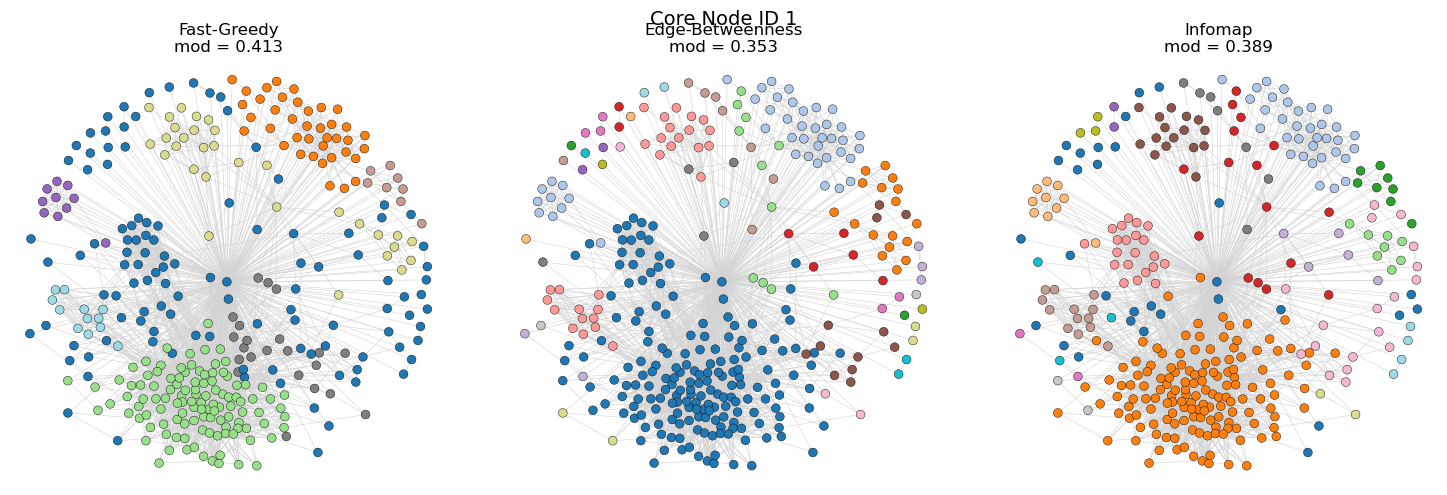

In [11]:
plot_node(0)

In [14]:
plot_node(107)

KeyboardInterrupt: 

Core Node ID 349  (|V|=230, |E|=3441)
  Fast-Greedy: 5 communities, mod = 0.2517
  Edge-Betweenness: 104 communities, mod = 0.1335
  Infomap: 9 communities, mod = 0.2084


/var/folders/gb/1g8q_x1s6b5f1v2vhkpp1qvw0000gn/T/ipykernel_27420/753667394.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k)


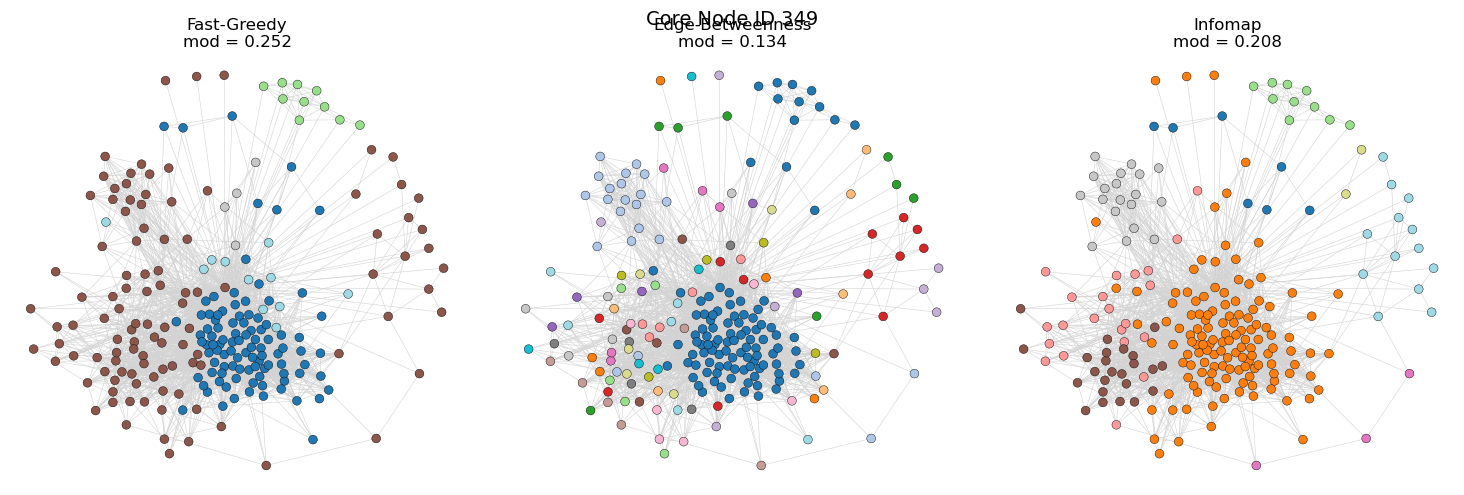

In [11]:
plot_node(348)

Core Node ID 484  (|V|=232, |E|=4525)
  Fast-Greedy: 3 communities, mod = 0.5070
  Edge-Betweenness: 10 communities, mod = 0.4891
  Infomap: 4 communities, mod = 0.5153


/var/folders/gb/1g8q_x1s6b5f1v2vhkpp1qvw0000gn/T/ipykernel_27420/753667394.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k)


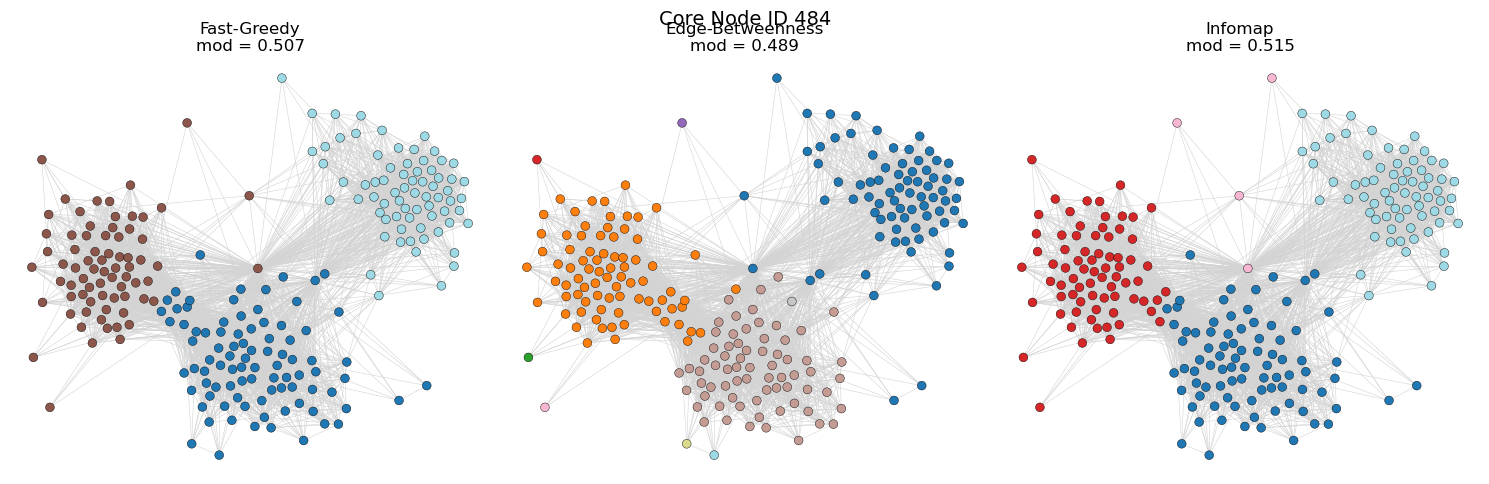

In [12]:
plot_node(483)

Core Node ID 1087  (|V|=206, |E|=7409)
  Fast-Greedy: 2 communities, mod = 0.1455
  Edge-Betweenness: 9 communities, mod = 0.0276
  Infomap: 4 communities, mod = 0.0269


/var/folders/gb/1g8q_x1s6b5f1v2vhkpp1qvw0000gn/T/ipykernel_27420/753667394.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k)


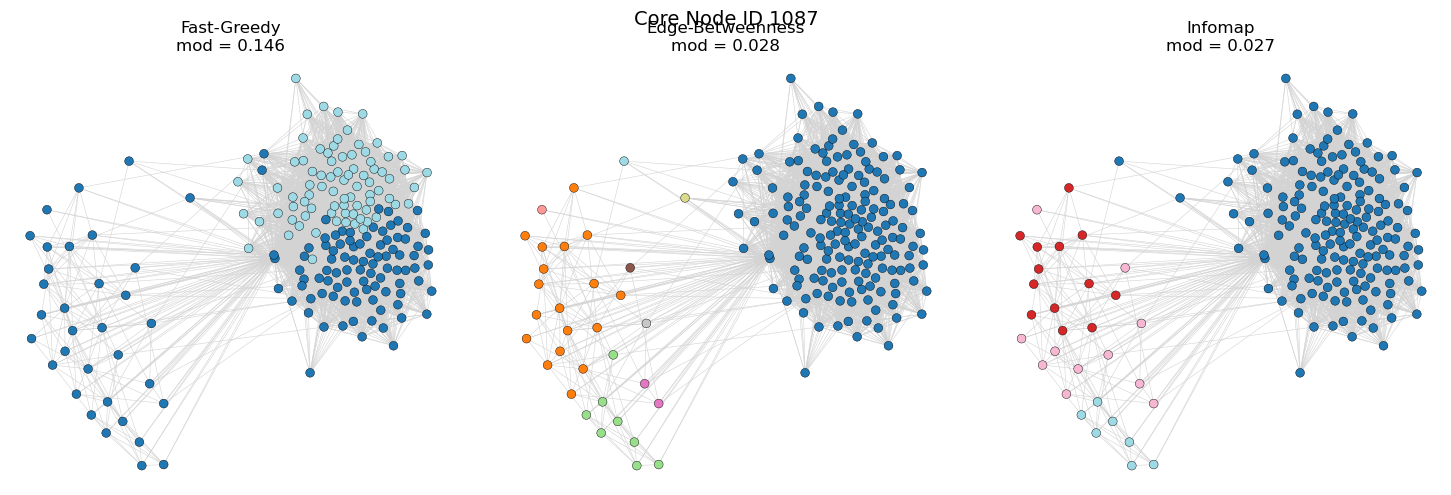

In [13]:
plot_node(1086)

### 3.2 Community Structure with the core node removed

#### 10

### 3.3 Characteristic of nodes in the personalized network

#### 11

#### 12

#### 13

#### 14

#### 15

### 4. Friend Recommendation in Personalized Networks

#### 16

#### 17

## 2. Google+ Network

In [60]:
import os
import os.path as path
import glob
import igraph as ig

def gplus_personal_networks(verbose=False):
    '''
    Reads the directory gplus/ files and creates personal networks.
    '''
    # Path to gplus/ directory
    current_dir = path.join(os.getcwd(), 'gplus')
    
    # Find all .circles files
    circles_files = glob.glob(os.path.join(current_dir, "*.circles"))
    
    if verbose: print(f"Found {len(circles_files)} total ego nodes")
    
    # Iterate through each user
    networks = {}
    for circles_fpath in circles_files:
        # Extract nodeId from filename (e.g., "12345.circles" -> "12345")
        filename = path.basename(circles_fpath)
        node_id = filename.split(".")[0]  # Ego node
        
        # Count number of circles for this ego node
        with open(circles_fpath, "r") as f:
            circles = f.readlines()
        
        # Only consider those with 2+ circles
        if len(circles) <= 2:
            if verbose: print(f"Node id {node_id} had <= 2 circles")
            continue
            
        if verbose: print(f"Ego Node: {node_id} ({len(circles)} circles found)")
        
        # Parse same node's .edges file
        edges_fpath = path.join(current_dir, f"{node_id}.edges")
        if not path.exists(edges_fpath) or path.getsize(edges_fpath) == 0:
            # Skip if the file is empty or missing
            continue
            
        # Read network connections
        network_edges = []
        unique_nodes = set()
        with open(edges_fpath, "r") as f:
            for line in f:
                # gplus edges are directed, 'a follows b' (a -> b)
                source, target = line.strip().split()
                network_edges.append((source, target))
                unique_nodes.add(source)
                unique_nodes.add(target)
                
        # Add ego node and its connections
        # .readme says ego node doesn't appear in .edges file, but
        # make the ego node follow every node id that appears in file
        unique_nodes.add(node_id)
        for neighbor in unique_nodes:
            if neighbor != node_id:
                network_edges.append((node_id, neighbor)) # Ego follows neighbor
                
        # Map string IDs to unique integer IDs for igraph compatibility
        # (igraph requires internal vertex indices to be sequential integers)
        sorted_nodes = sorted(list(unique_nodes))
        id_map = {node_id: idx for idx, node_id in enumerate(sorted_nodes)}
        mapped_edges = [(id_map[src], id_map[tgt]) for src, tgt in network_edges]
        
        # Create directed graph
        g = ig.Graph(directed=True)
        g.add_vertices(len(unique_nodes))
        g.add_edges(mapped_edges)
        if verbose: print(f"   Created personal network with {g.vcount()} nodes and {g.ecount()} directed edges.")
    
        # Add extra data for later
        # Store original SNAP IDs
        # Organized like Pandas DataFrame. Index is a node and has columns/attributes (e.g., snap_id)
        g.vs["snap_id"] = sorted_nodes  # Assigns each vertex to one node
        # Flag ego node explicitly
        g.vs["is_ego"] = [uid == node_id for uid in sorted_nodes]

        # Store for output
        networks[node_id] = g

    return networks

#### 18 

In [13]:
gplus_networks = gplus_personal_networks()
n_networks = len(gplus_networks)
print(f"There are {n_networks} personal networks")

There are 57 personal networks


#### 19

In [27]:
import matplotlib.pyplot as plt

def plot_degree_distributions(node_id, networks):
    '''
    Plots the in-degree and out-degree distributions of a personal network.
    '''
    
    # In-degrees and out-degrees for all vertices in specific network
    g = networks[node_id]
    in_degrees = g.indegree()
    out_degrees = g.outdegree()
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"Degree Distributions for Personal Network: {node_id}", fontsize=16, fontweight='bold')
    
    # In-degree
    axes[0].hist(in_degrees, density=True, color="skyblue", edgecolor="black", alpha=0.7, rwidth=0.85)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Clean background gridlines
    axes[0].set_title("In-Degree Distribution (Followed By)", fontsize=13)
    axes[0].set_xlabel("In-Degree ($k_{in}$)")
    axes[0].set_ylabel("Count / Frequency")
    
    # Out-degree
    axes[1].hist(out_degrees, density=True, color="salmon", edgecolor="black", alpha=0.7, rwidth=0.85)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    axes[1].set_title("Out-Degree Distribution (Following)", fontsize=13)
    axes[1].set_xlabel("Out-Degree ($k_{out}$)")
    plt.tight_layout()
    plt.show()


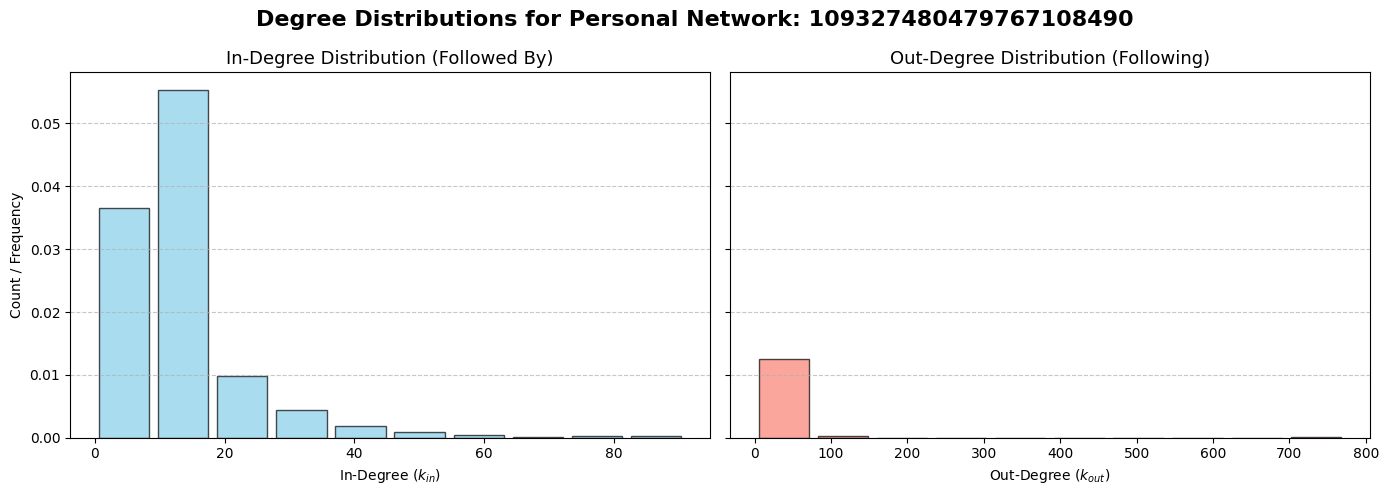

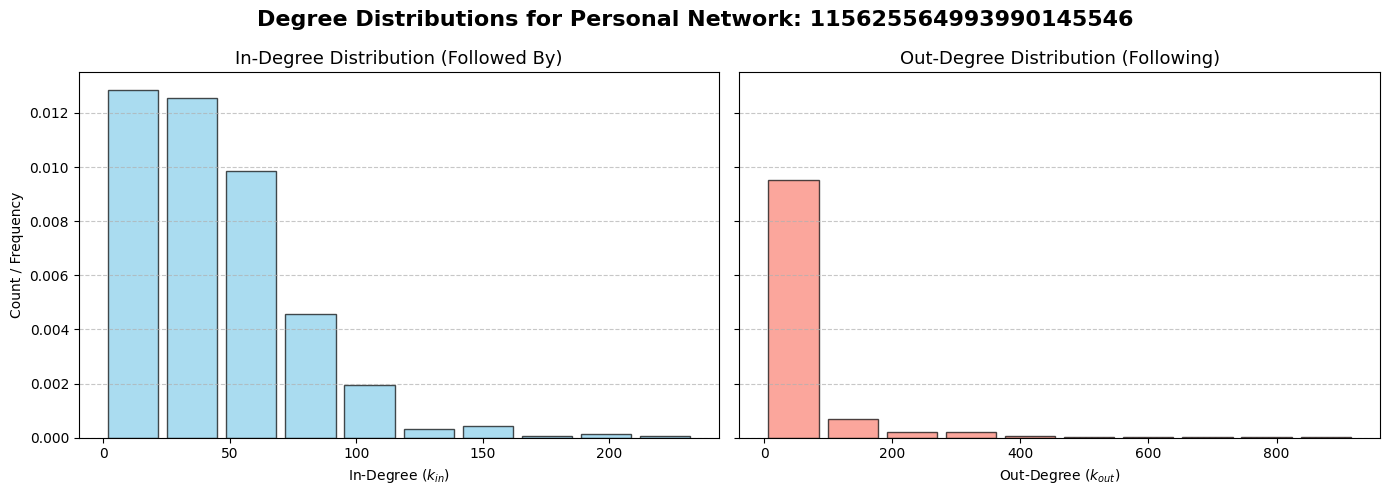

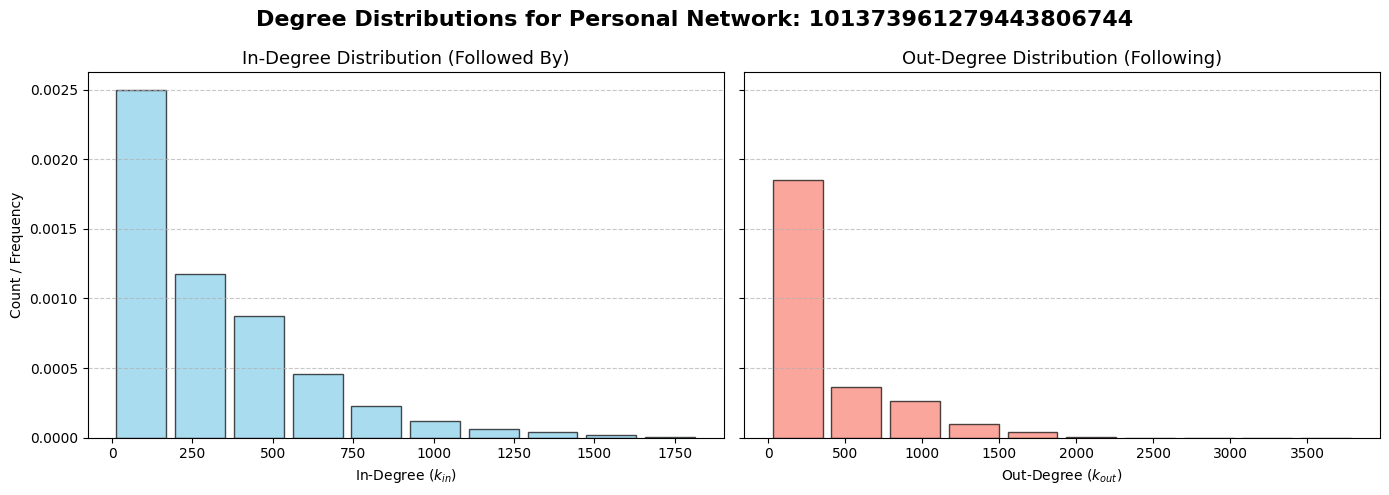

In [28]:
specific_ids = ['109327480479767108490', '115625564993990145546', '101373961279443806744']
for myid in specific_ids:
    plot_degree_distributions(myid, gplus_networks)

The 3 personal networks above do not have similar in- and out-degree distributions.

### 1. Community structure of personal networks

#### 20

In [29]:
def plot_walktrap_communities(node_id, gplus_networks):
    '''
    Performs a Walktrap community detection algorithm for a given node.
    '''
    g = gplus_networks[node_id]
    # Run Walktrap
    dendrogram = g.community_walktrap()
    # Returns partition cut at the maximum index modularity 
    communities = dendrogram.as_clustering()
    # Modularity scores
    modularity_score = communities.modularity

    # Plot communities
    fig, ax = plt.subplots(figsize=(8, 8))
    ig.plot(
        communities,
        target=ax,
        vertex_size=15,
        vertex_label=None,  # Hide labels so the plot isn't cluttered
        edge_arrow_size=0.5,
        edge_width=0.5
    )
    
    ax.set_title(f"Walktrap Communities for Ego: {node_id}\nModularity (Q) = {modularity_score:.4f}", 
                 fontsize=14, fontweight='bold')
    plt.show()

    return modularity_score


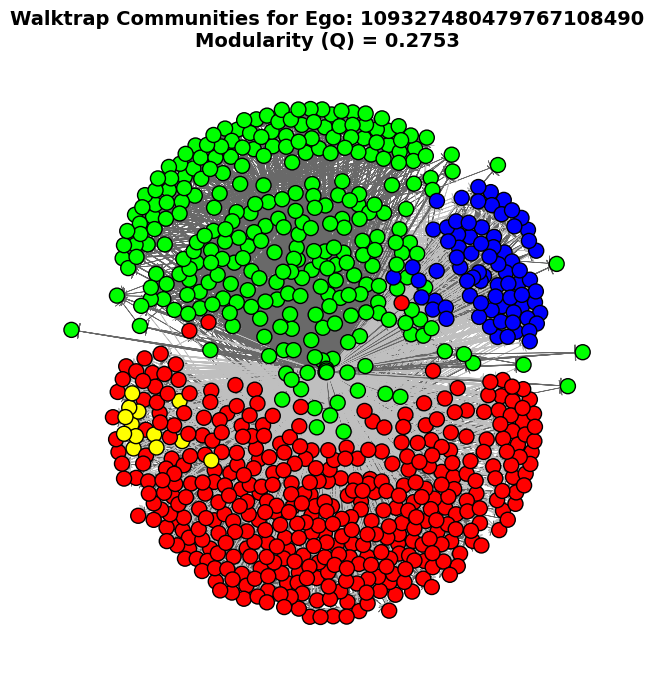

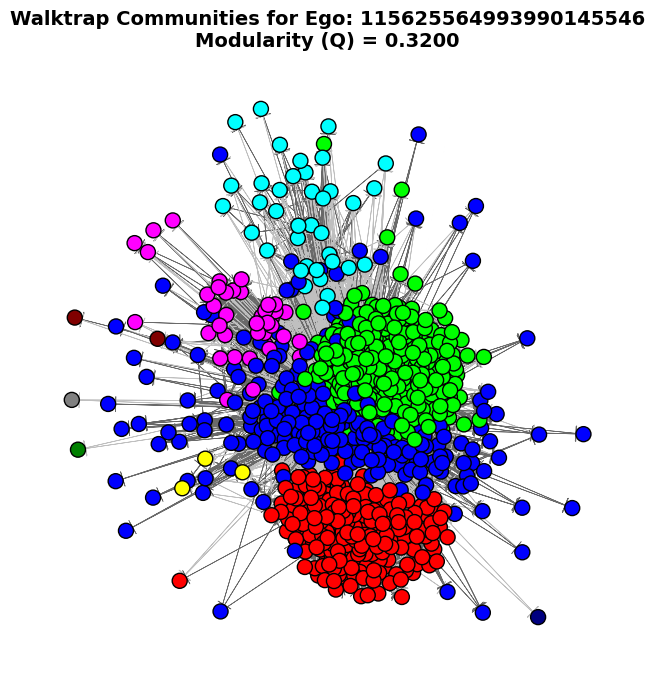

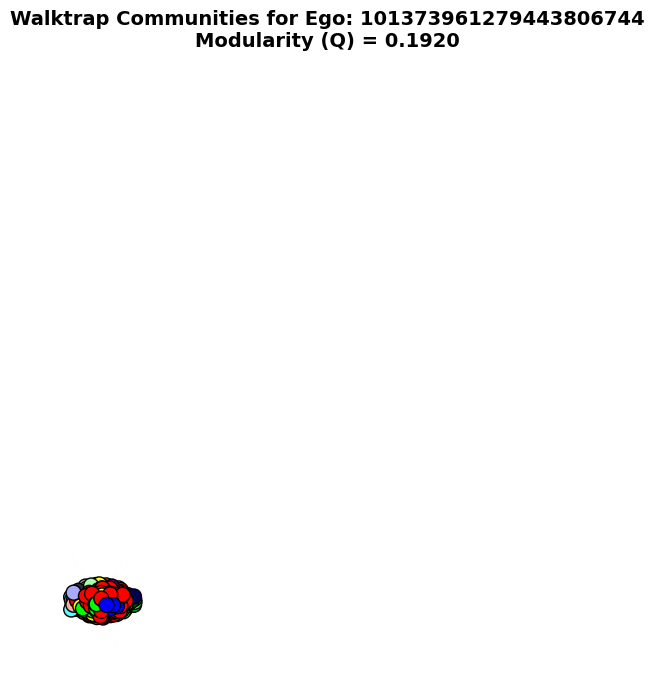

Modularity Scores:
---------------------
Node ID 109327480479767108490: Modularity score 0.2753
Node ID 115625564993990145546: Modularity score 0.3200
Node ID 101373961279443806744: Modularity score 0.1920


In [33]:
# Walktrap community detection algorithm
specific_ids = ['109327480479767108490', '115625564993990145546', '101373961279443806744']

modularity_scores = []
for node_id in specific_ids:
    mod_score = plot_walktrap_communities(node_id, gplus_networks)
    modularity_scores.append(mod_score)

print('Modularity Scores:\n---------------------')
for node_id, mscore in zip(specific_ids, modularity_scores):
    print(f'Node ID {node_id}: Modularity score {mscore:.4f}')

The last plot looks smushed because there is poor community separation as indicated by the low modularity index value in comparison to the previous two. In other words, there is likely just a single large giant component, which explains why the plot is smushed into a single foci.

#### 21

Homogeneity is a measure of how similar the communities partitioned by an algorithm are to the actual ground-truth circles. A single community is considered perfectly homogenous if its members contain the same members as a given circle. Extending this thought to the entire network, a homogenous network is one with its communities closely resembling the actual circles.

Completeness is a measure of how similar the circles are to the communities partitioned by an algorithm. A circle is considered perfectly complete if all its members are placed in the same community by the algorithm; conversely, an incomplete circle means its members were split up into different communities. As such, a network with high completeness means the circles were preserved well across all the communities.

#### 22

In [30]:
def gplus_circles():
    '''
    Reads the directory gplus/ files and reads in the set of circles for each ego node.
    '''
    # Find all .circles files
    current_dir = path.join(os.getcwd(), 'gplus')
    circles_files = glob.glob(os.path.join(current_dir, "*.circles"))
    
    # Iterate through each user
    network_circles = {}
    for circles_fpath in circles_files:
        # Extract nodeId from filename (e.g., "12345.circles" -> "12345")
        filename = path.basename(circles_fpath)
        node_id = filename.split(".")[0]  # Ego node
        
        # Parse circles for this ego node
        circles = {}
        with open(circles_fpath, "r") as f:
            for line in f.readlines():
                tokens = line.strip().split()
                if not tokens: continue
                circle_id = tokens[0]
                node_ids = [str(tok) for tok in tokens[1:]]
                circles[circle_id] = node_ids

        # Cache circles for nodeId
        network_circles[node_id] = circles

    return network_circles

In [62]:
import numpy as np

def compute_homogeneity_and_completeness(node_id, g, communities, circles, all_nodes):
    '''
    Computes the homogeneity and completeness scores for a given network `g`
    and accompanying `user_circles`.
    '''
    N = len(all_nodes)
    if N == 0: 
        print('WARNING: This graph has zero nodes!')
        return 0, 0

    C_list = list(circles.values())
    K_list = communities
    
    num_circles = len(C_list)     # |C|
    num_communities = len(K_list) # |K|
    if num_circles == 0 or num_communities == 0:
        print(f'WARNING: num_circles={num_circles}, num_communities={num_communities}')
        return 0, 0

    # Matrix A: number of people belonging to community j and circle i
    A = np.zeros((num_communities, num_circles))
    for j, community in enumerate(K_list):
        # Cast all IDs to str to avoid set mismatch bugs
        # Extract IDs and *exclude* the main ego node_id (accounting for .circles format)
        set_K = {
            str(g.vs[node_idx]['snap_id'])
            for node_idx in community
            if str(g.vs[node_idx]['snap_id']) != str(node_id)
            }
        for i, circle in enumerate(C_list):
            set_C = set(str(circ) for circ in circle)
            A[j, i] = len(set_K.intersection(set_C))
    
    # Calculate N (total number of people with circle information)
    N = np.sum(A)
    if N == 0:
        print('WARNING: Zero assignments')
        return 0, 0
    
    # Entropies H(C) and H(K)
    a = np.sum(A, axis=0) # Number of people in circle C_i
    b = np.sum(A, axis=1) # Number of people in community K_j
    def entropy(values):
        values_ = values[values > 0]
        return -np.sum(values_ * np.log(values_))
    H_C = entropy(a / N)
    H_K = entropy(b / N)
    
    # Conditional entropies
    H_C_K = 0.0
    for j in range(num_communities):
        if b[j] > 0:
            for i in range(num_circles):
                if A[j, i] > 0:
                    H_C_K += (A[j, i] / N) * np.log(A[j, i] / b[j])
    H_C_K *= -1

    H_K_C = 0.0
    for i in range(num_circles):
        if a[i] > 0:
            for j in range(num_communities):
                if A[j, i] > 0:
                    H_K_C += (A[j, i] / N) * np.log(A[j, i] / a[i])
    H_K_C *= -1

    # Computing h and c
    h = 1.0 - (H_C_K / H_C) if H_C > 0 else 1.0
    c = 1.0 - (H_K_C / H_K) if H_K > 0 else 1.0

    return h, c 

In [63]:
def characterize_networks(node_id, gplus_networks, networks_circles):
    '''
    Characterizes the network for a given node ID by computing the homogeneity
    and completeness values.
    '''
    # Get network and circles for user_id
    g = gplus_networks[node_id]
    user_circles = networks_circles[node_id]

    # Obtain communities
    dendrogram = g.community_walktrap()
    communities = dendrogram.as_clustering()
    n_communities = len(communities)

    # Compute homogeneity and completeness
    all_nodes = g.vs['snap_id']
    h, c = compute_homogeneity_and_completeness(node_id, g, communities, user_circles, all_nodes)
    print(f"(Node ID: {node_id}) h={h:.4f}, c={c:.4f}")

In [64]:
# Compute h and c
specific_ids = ['109327480479767108490', '115625564993990145546', '101373961279443806744']
network_circles = gplus_circles()
for node_id in specific_ids:
    characterize_networks(node_id, gplus_networks, network_circles)

(Node ID: 109327480479767108490) h=0.5249, c=0.5497
(Node ID: 115625564993990145546) h=0.1060, c=0.3822
(Node ID: 101373961279443806744) h=0.0004, c=0.0009


## 3. Cora dataset

#### 23